<a href="https://colab.research.google.com/github/Sarthak196011/AI-PROJECT/blob/main/Prime_trade_AI_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [ ]:
df2.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [ ]:
df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [ ]:
df2.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
df.nunique()

,0
Account,32
Coin,246
Execution Price,60162
Size Tokens,59304
Size USD,118493
Side,2
Timestamp IST,27977
Start Position,196923
Direction,12
Closed PnL,90720


In [ ]:
df2.nunique()

,0
timestamp,2644
value,90
classification,5
date,2644


In [ ]:
df['Timestamp IST'] = pd.to_datetime(df['Timestamp IST'], format='%d-%m-%Y %H:%M')
df['date'] = df['Timestamp IST'].dt.date
df['date'] = pd.to_datetime(df['date'])

df2['date'] = pd.to_datetime(df2['date'])
merged_df = pd.merge(df, df2[['date', 'value', 'classification']], on='date', how='left')
display(merged_df.head())

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


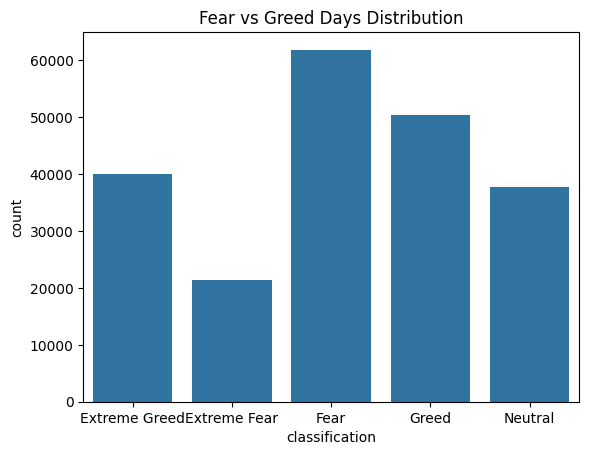

In [ ]:
sns.countplot(x='classification', data=merged_df)
plt.title('Fear vs Greed Days Distribution')
plt.show()

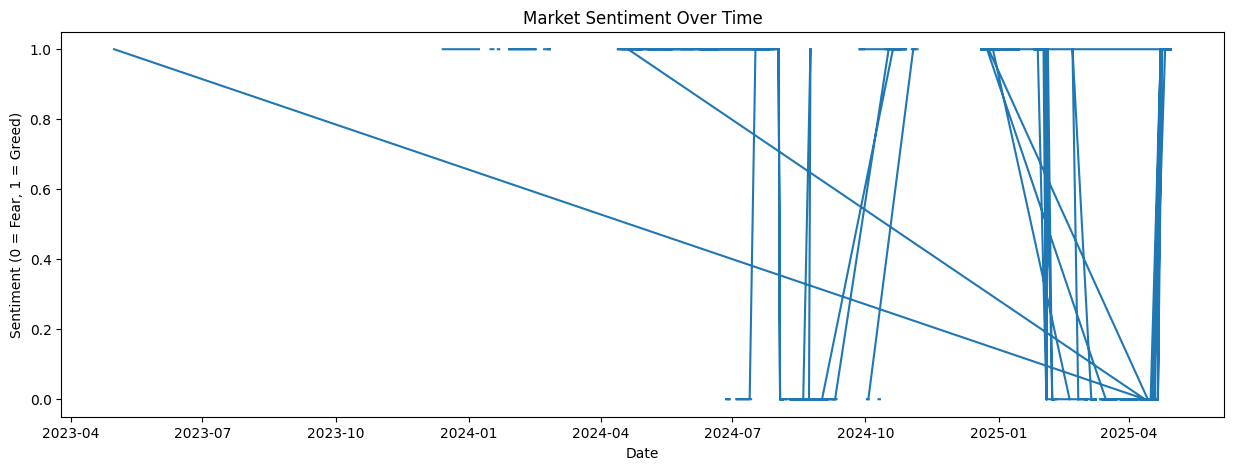

In [ ]:
merged_df['Classification_Code'] = merged_df['classification'].map({'Fear': 0, 'Greed': 1})
plt.figure(figsize=(15,5))
plt.plot(merged_df['date'], merged_df['Classification_Code'])
plt.xlabel('Date')
plt.ylabel('Sentiment (0 = Fear, 1 = Greed)')
plt.title('Market Sentiment Over Time')
plt.show()

In [ ]:
merged_df['Shift'] = merged_df['classification'].ne(merged_df['classification'].shift())
merged_df['Group'] = merged_df['Shift'].cumsum()
periods = merged_df.groupby(['Group', 'classification']).agg({'date': ['min', 'max', 'count']}).reset_index()
print(periods.sort_values(('date', 'count'), ascending=False).head(5))

    Group classification       date                 
                                min        max count
390   397           Fear 2025-03-14 2025-04-06  5460
738   745  Extreme Greed 2024-12-12 2024-12-19  4536
383   390        Neutral 2025-02-20 2025-02-24  4268
38     45           Fear 2025-04-14 2025-04-21  3897
600   607  Extreme Greed 2024-11-16 2024-12-05  3873


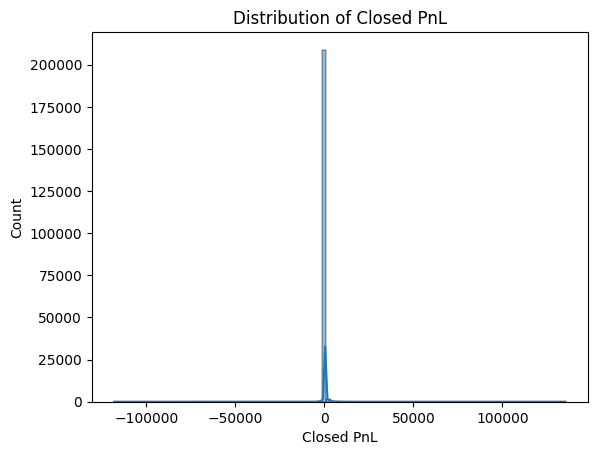

In [ ]:
sns.histplot(merged_df['Closed PnL'], bins=100, kde=True)
plt.title('Distribution of Closed PnL')
plt.xlabel('Closed PnL')
plt.show()

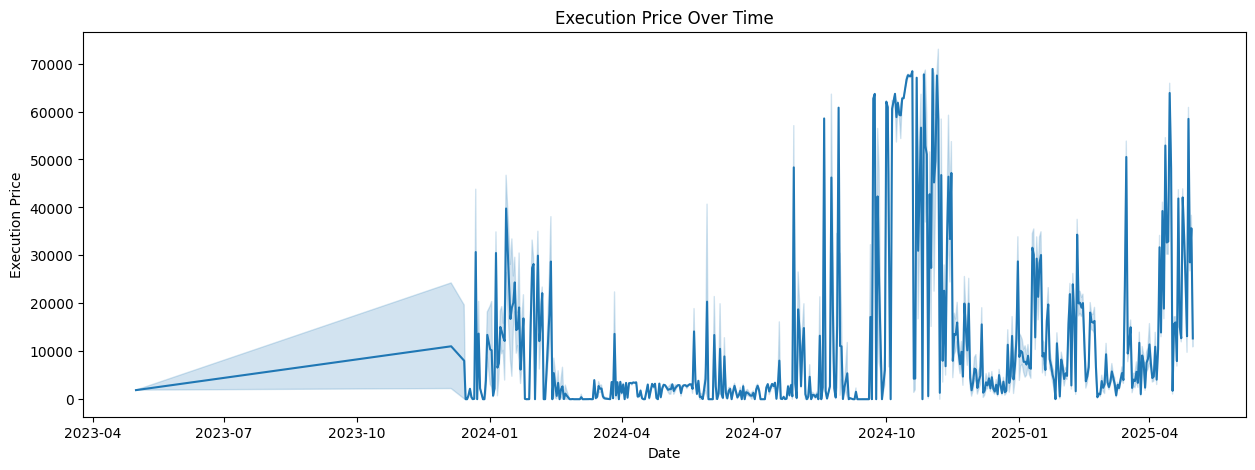

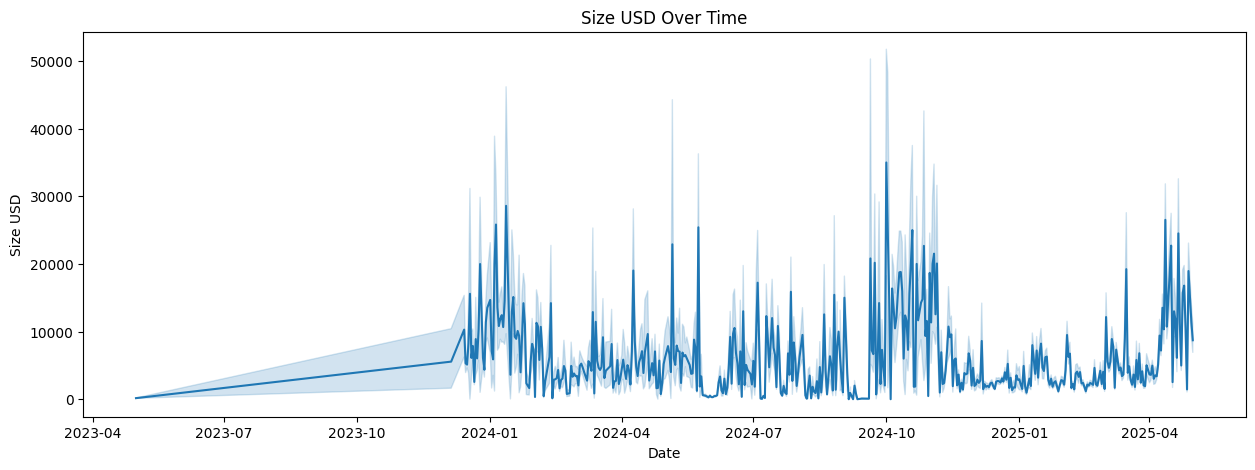

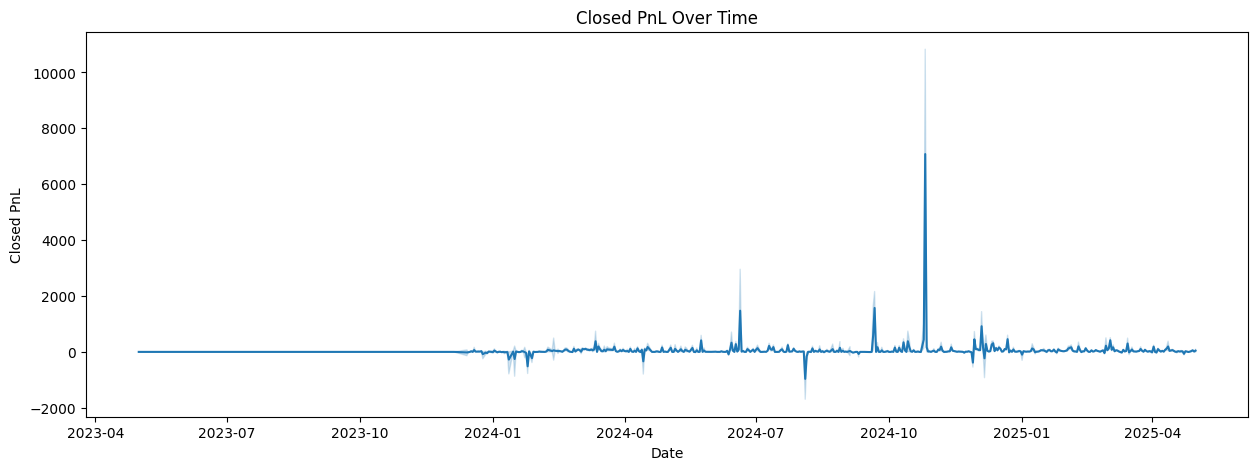

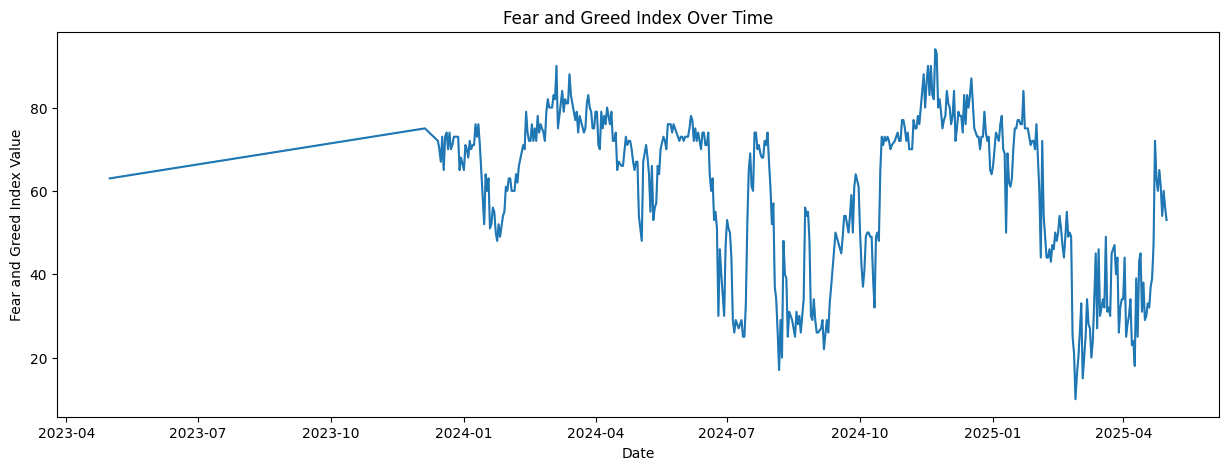

In [ ]:
plt.figure(figsize=(15, 5))
sns.lineplot(x='date', y='Execution Price', data=merged_df)
plt.title('Execution Price Over Time')
plt.xlabel('Date')
plt.ylabel('Execution Price')
plt.show()

plt.figure(figsize=(15, 5))
sns.lineplot(x='date', y='Size USD', data=merged_df)
plt.title('Size USD Over Time')
plt.xlabel('Date')
plt.ylabel('Size USD')
plt.show()

plt.figure(figsize=(15, 5))
sns.lineplot(x='date', y='Closed PnL', data=merged_df)
plt.title('Closed PnL Over Time')
plt.xlabel('Date')
plt.ylabel('Closed PnL')
plt.show()

plt.figure(figsize=(15, 5))
sns.lineplot(x='date', y='value', data=merged_df)
plt.title('Fear and Greed Index Over Time')
plt.xlabel('Date')
plt.ylabel('Fear and Greed Index Value')
plt.show()

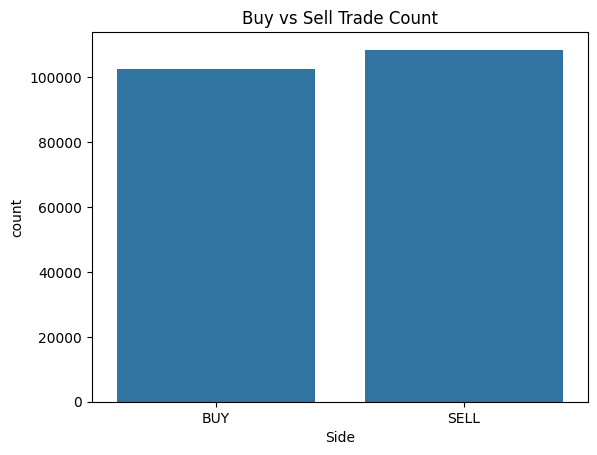

In [ ]:
sns.countplot(x='Side', data=merged_df)
plt.title('Buy vs Sell Trade Count')
plt.show()

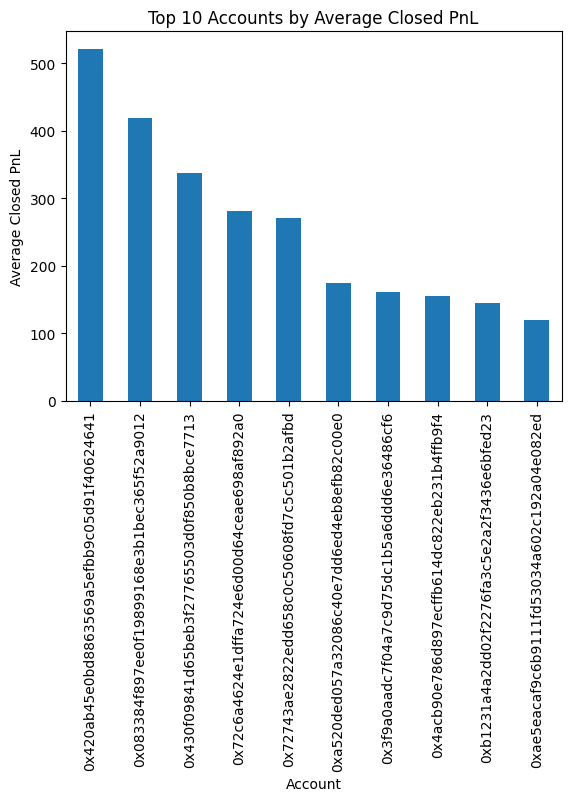

In [ ]:
account_perf = merged_df.groupby('Account')['Closed PnL'].mean().sort_values(ascending=False).head(10)
account_perf.plot(kind='bar')
plt.title('Top 10 Accounts by Average Closed PnL')
plt.ylabel('Average Closed PnL')
plt.show()

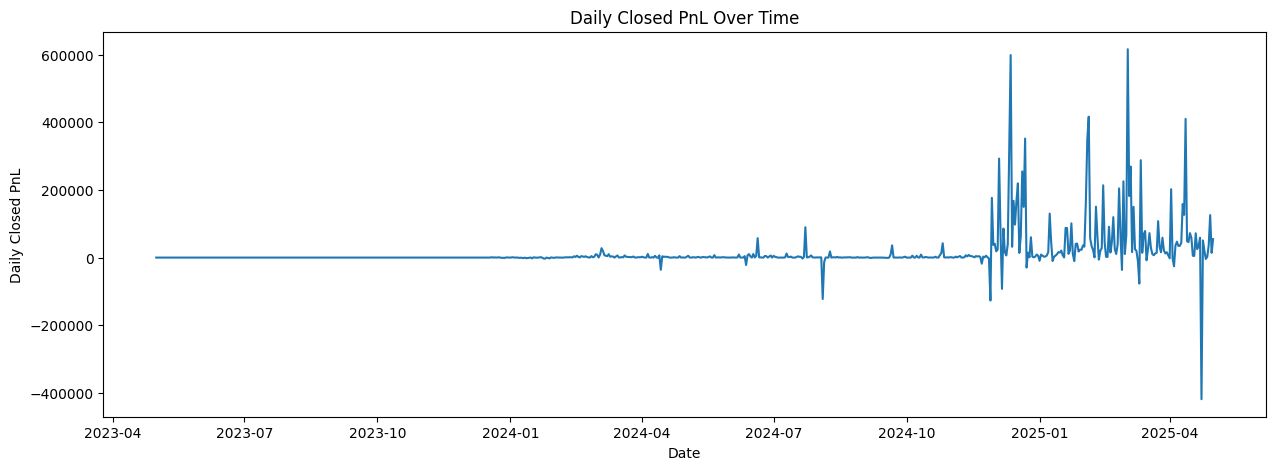

In [ ]:
daily_pnl = merged_df.groupby('date')['Closed PnL'].sum()
plt.figure(figsize=(15,5))
plt.plot(daily_pnl.index, daily_pnl.values)
plt.xlabel('Date')
plt.ylabel('Daily Closed PnL')
plt.title('Daily Closed PnL Over Time')
plt.show()

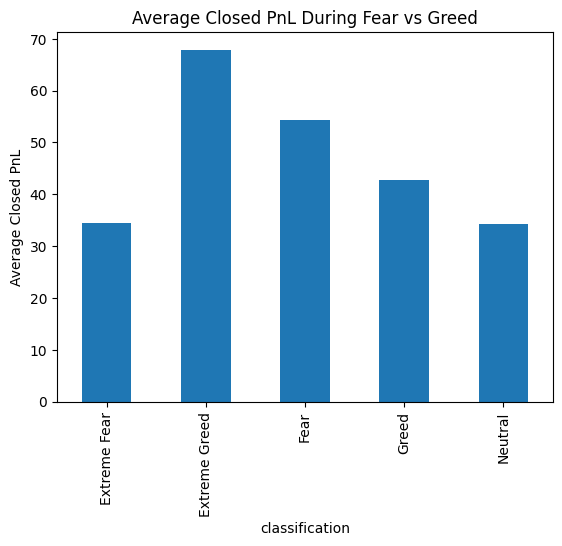

In [ ]:
merged_df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title('Average Closed PnL During Fear vs Greed')
plt.ylabel('Average Closed PnL')
plt.show()

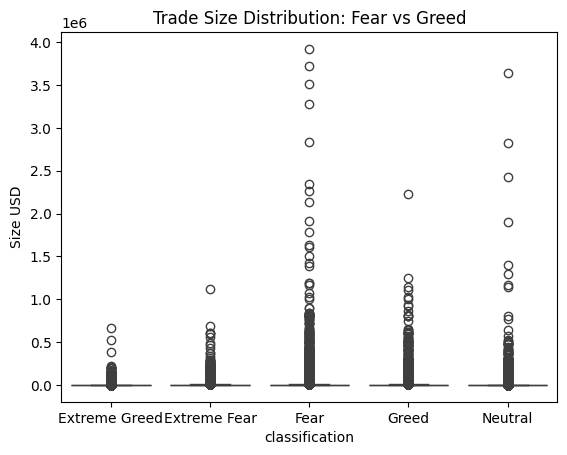

In [ ]:
sns.boxplot(x='classification', y='Size USD', data=merged_df)
plt.title('Trade Size Distribution: Fear vs Greed')
plt.show()

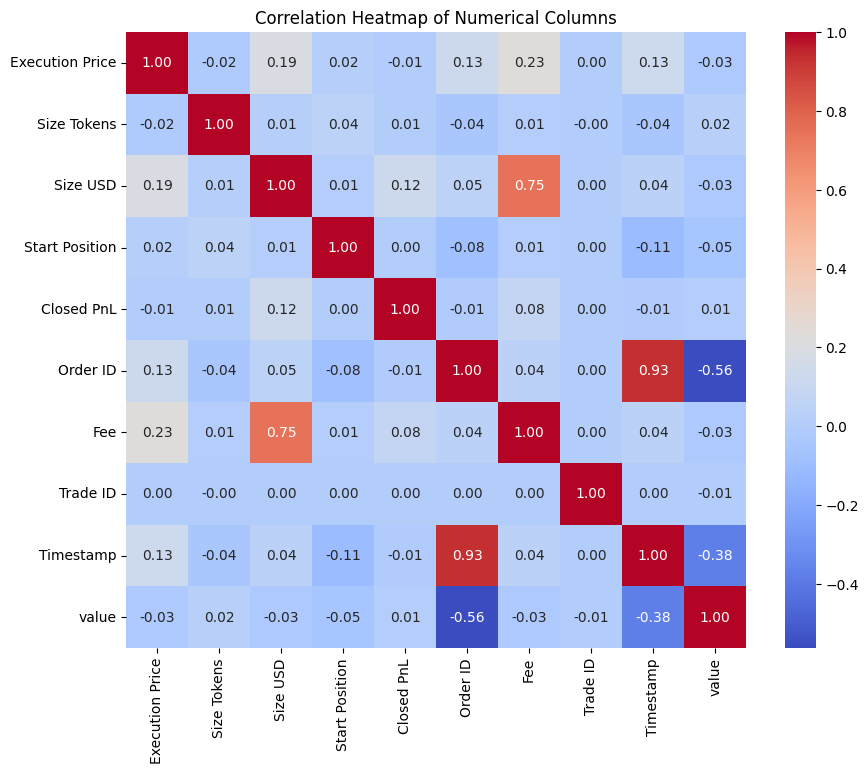

In [ ]:
correlation_matrix = merged_df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

## Project Outcomes Summary

Based on the analysis conducted, here are some key outcomes:

* **Data Overview:** We loaded and inspected two datasets (`df` and `df2`), which contain trading data and fear/greed index values respectively. Both datasets appear to be complete with no missing values.
* **Fear vs Greed Distribution:** The count plot of 'classification' shows the distribution of Fear vs Greed days in `merged_df`, indicating the frequency of different market sentiment classifications within the data.
* **Market Sentiment Over Time:** The line plot of 'Classification_Code' over time provides a visual representation of how market sentiment (categorized as Fear or Greed) changes over the analyzed period.
* **Duration of Sentiment Periods:** By grouping consecutive days of the same sentiment, we identified the longest periods of sustained Fear and Greed, as shown in the printed `periods` dataframe.
* **Closed PnL Distribution:** The histogram of 'Closed PnL' illustrates the distribution of trading profits and losses, giving an idea of the overall profitability of trades.
* **Time Series Analysis:** The line plots for 'Execution Price', 'Size USD', 'Closed PnL', and 'Fear and Greed Index Value' over time reveal trends and patterns in these key metrics.
* **Trade Side Distribution:** The count plot of 'Side' shows the number of buy versus sell trades, indicating the overall trading activity direction.
* **Account Performance:** The bar plot of the top 10 accounts by average 'Closed PnL' highlights the most profitable accounts in the dataset.
* **Daily Closed PnL:** The line plot of daily total 'Closed PnL' shows the aggregate daily performance of all accounts.
* **Sentiment and Profitability:** The bar plot comparing average 'Closed PnL' during Fear vs Greed periods provides insights into how market sentiment might influence trading outcomes.
* **Trade Size and Sentiment:** The box plot of 'Size USD' by 'classification' shows the distribution of trade sizes during different sentiment periods.
* **Correlation Analysis:** The heatmap of numerical columns reveals the correlation between various numerical features in the merged dataset.

These visualizations and analyses provide a foundational understanding of the trading data and its relationship with market sentiment, allowing for further, more in-depth investigations.